In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

import datetime

from numpy.random import choice

import logging

### Load data

In [5]:
path = 'data'
data = pd.DataFrame()
for file in os.listdir(path):
    df = pd.read_csv(os.path.join(path,file), sep=';')
    df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y-%m-%d %H:%M:%S")
    data = pd.concat([data,df])
data = data.sort_values(by=['timestamp']).reset_index(drop=True)

In [6]:
aisles = ['fruit', 'spices', 'dairy', 'drinks', 'checkout']
aisles

['fruit', 'spices', 'dairy', 'drinks', 'checkout']

### Get customer locations, times and durations as rows

In [7]:
plot_data = data.sort_values(by=['timestamp'])#.copy()
plot_data['day'] = plot_data['timestamp'].dt.dayofweek
idx = plot_data.groupby(['day', 'customer_no']).all().index
df_times = pd.DataFrame(index=idx)
df_durations = pd.DataFrame(index=idx)
df_locations = pd.DataFrame(index=idx)

max_sections = plot_data.groupby(['day', 'customer_no'])['location'].count().max()
for n in range(max_sections):
    df_times[n] = plot_data.groupby(['day','customer_no']).nth(n)['timestamp']
    
    df_locations[n] = plot_data.groupby(['day','customer_no']).nth(n)['location']
    
    if n>0:
        df_durations[n-1] = (df_times[n] - df_times[n-1]).dt.seconds
    
#df_durations

### Probability mass function for first aisle visited

In [8]:
# get probabilities for first aisle visited
first_aisle_proba = pd.DataFrame(index=aisles)

first_aisle_proba['all days'] = df_locations[0].value_counts() / df_locations[0].count()

for day in df_locations.index.levels[0]:
    first_aisle_proba[f'day {day}'] = df_locations.loc[day,0].value_counts() / df_locations.loc[day,0].count()

In [9]:
first_aisle_proba

,all days,day 0,day 1,day 2,day 3,day 4
fruit,0.377435,0.359364,0.393108,0.378184,0.368730,0.388079
spices,0.181464,0.195577,0.159634,0.163945,0.194137,0.193377
dairy,0.287576,0.284727,0.292546,0.301764,0.295114,0.263576
drinks,0.153526,0.160332,0.154712,0.156107,0.142020,0.154967
checkout,NaN,NaN,NaN,NaN,NaN,NaN


### Transition probabilities

#####  For all days, from each location to the next without consideration of time

In [261]:
a

'checkout'

In [260]:
instances_a

(array([   0,    1,    2, ..., 7438, 7441, 7442]),
 array([1, 1, 1, ..., 1, 1, 1]))

In [263]:
total_transitions

start aisle
fruit       5115.0
spices      3749.0
dairy       4665.0
drinks      3903.0
checkout       0.0
dtype: float64

In [266]:
transition_matrix

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,NaN,644,1219,697,2555
spices,571,NaN,1213,1024,941
dairy,886,913,NaN,1041,1825
drinks,855,846,106,NaN,2096
checkout,NaN,NaN,NaN,NaN,NaN


In [268]:
a

'checkout'

In [267]:
instances_next

(array([   0,    1,    2, ..., 7438, 7441, 7442]),
 array([2, 2, 2, ..., 2, 2, 2]))

In [269]:
pd.Series(dummy_locations.values[instances_next]).value_counts()

Series([], dtype: int64)

In [ ]:
dummy_locations.fillna(method='ffill', axis=1)

In [275]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix.index.rename('start aisle', inplace=True)
transition_matrix.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.fillna(method='ffill', axis=1)
dummy_locations[999] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles:#[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba = transition_matrix.div(total_transitions,axis=0)
transition_proba

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.019927,0.123395,0.233570,0.133550,0.489557
spices,0.149398,0.019100,0.317373,0.267923,0.246206
dairy,0.181557,0.187090,0.044057,0.213320,0.373975
drinks,0.217226,0.214939,0.026931,0.008384,0.532520
checkout,NaN,NaN,NaN,NaN,1.000000


In [274]:
transition_proba

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,NaN,0.125904,0.238319,0.136266,0.499511
spices,0.152307,NaN,0.323553,0.27314,0.251
dairy,0.189925,0.195713,NaN,0.223151,0.391211
drinks,0.219062,0.216756,0.0271586,NaN,0.537023


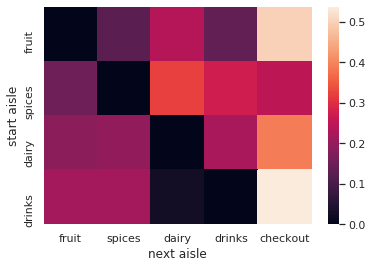

In [11]:
sns.heatmap(transition_proba.fillna(0));

#####  For individual days, from each location to the next without consideration of time

In [12]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles[:-1]], names=['day','start aisle'])
transition_matrix_by_day = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day.index.rename('start aisle', inplace=True)
transition_matrix_by_day.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.copy()
dummy_locations[999] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles[:-1]:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day = transition_matrix_by_day.div(total_transitions_by_day,axis=0)
transition_proba_by_day

next aisle          fruit    spices      dairy    drinks  checkout
day start aisle                                                   
all fruit             NaN  0.125904   0.238319  0.136266  0.499511
    spices       0.152307       NaN   0.323553   0.27314     0.251
    dairy        0.189925  0.195713        NaN  0.223151  0.391211
    drinks       0.219062  0.216756  0.0271586       NaN  0.537023
0   fruit             NaN  0.121878   0.224775   0.12987  0.523477
    spices       0.159091       NaN   0.314171  0.290107  0.236631
    dairy         0.20202  0.205387        NaN  0.244669  0.347924
    drinks       0.233375  0.203262  0.0288582       NaN  0.534504
1   fruit             NaN  0.131148   0.237705  0.132172  0.498975
    spices       0.144092       NaN   0.354467  0.262248  0.239193
    dairy        0.184818  0.206821        NaN   0.20022  0.408141
    drinks       0.208976  0.211781  0.0238429       NaN    0.5554
2   fruit             NaN  0.117195   0.243996  0.126801  0.512008
    spices       0.146776       NaN   0.323731   0.26749  0.262003
    dairy        0.177618  0.201232        NaN  0.214579  0.406571
    drinks       0.237419  0.207742  0.0309677       NaN  0.523871
3   fruit             NaN  0.134486   0.225744  0.132565  0.507205
    spices       0.150633       NaN   0.322785  0.265823  0.260759
    dairy        0.201663  0.183992        NaN  0.218295   0.39605
    drinks       0.208763  0.225515  0.0283505       NaN  0.537371
4   fruit             NaN     0.125   0.258523  0.159091  0.457386
    spices       0.159898       NaN   0.305838  0.279188  0.255076
    dairy        0.184069  0.181916        NaN  0.238967  0.395048
    drinks       0.206651  0.233967   0.023753       NaN  0.535629

## Recalculate the transition matrix using a timestep of 1 minute

In [276]:
df_location_by_time = data.sort_values(by=['customer_no', 'timestamp'])
df_location_by_time['day'] = df_location_by_time['timestamp'].dt.dayofweek
entrance_time = df_location_by_time.groupby(['day', 'customer_no']).nth(0)['timestamp']
df_location_by_time = df_location_by_time.set_index(['day', 'customer_no'])
time_elapsed = df_location_by_time['timestamp'] - entrance_time
df_location_by_time['time_elapsed'] = time_elapsed.sort_index(level=1).values ### THIS IS A BIT HAIRY - add unique index ###
df_location_by_time = df_location_by_time.reset_index().set_index(['day', 'customer_no','time_elapsed'])['location']
df_location_by_time = df_location_by_time.unstack(-1).reindex(pd.timedelta_range('00S', '3600S', freq='60S'), axis=1) 
df_location_by_time = df_location_by_time.fillna(method='ffill', axis=1)
df_location_by_time

00:00:00  00:01:00  00:02:00  00:03:00  00:04:00  00:05:00  \
day customer_no                                                              
0   1              dairy     dairy  checkout  checkout  checkout  checkout   
    2              dairy     dairy     dairy  checkout  checkout  checkout   
    3              dairy     dairy  checkout  checkout  checkout  checkout   
    4              dairy     dairy     dairy     dairy  checkout  checkout   
    5             spices  checkout  checkout  checkout  checkout  checkout   
...                  ...       ...       ...       ...       ...       ...   
4   1506           dairy     dairy     dairy     dairy     dairy     dairy   
    1507           dairy     dairy  checkout  checkout  checkout  checkout   
    1508           dairy     dairy  checkout  checkout  checkout  checkout   
    1509          drinks    drinks    drinks    drinks    drinks    drinks   
    1510          spices    spices    spices    spices    spices    spices   

                 00:06:00  00:07:00  00:08:00  00:09:00  ...  00:51:00  \
day customer_no                                          ...             
0   1            checkout  checkout  checkout  checkout  ...  checkout   
    2            checkout  checkout  checkout  checkout  ...  checkout   
    3            checkout  checkout  checkout  checkout  ...  checkout   
    4            checkout  checkout  checkout  checkout  ...  checkout   
    5            checkout  checkout  checkout  checkout  ...  checkout   
...                   ...       ...       ...       ...  ...       ...   
4   1506            dairy     dairy     dairy     dairy  ...     dairy   
    1507         checkout  checkout  checkout  checkout  ...  checkout   
    1508         checkout  checkout  checkout  checkout  ...  checkout   
    1509           drinks    drinks    drinks    drinks  ...    drinks   
    1510           spices    spices    spices    spices  ...    spices   

                 00:52:00  00:53:00  00:54:00  00:55:00  00:56:00  00:57:00  \
day customer_no                                                               
0   1            checkout  checkout  checkout  checkout  checkout  checkout   
    2            checkout  checkout  checkout  checkout  checkout  checkout   
    3            checkout  checkout  checkout  checkout  checkout  checkout   
    4            checkout  checkout  checkout  checkout  checkout  checkout   
    5            checkout  checkout  checkout  checkout  checkout  checkout   
...                   ...       ...       ...       ...       ...       ...   
4   1506            dairy     dairy     dairy     dairy     dairy     dairy   
    1507         checkout  checkout  checkout  checkout  checkout  checkout   
    1508         checkout  checkout  checkout  checkout  checkout  checkout   
    1509           drinks    drinks    drinks    drinks    drinks    drinks   
    1510           spices    spices    spices    spices    spices    spices   

                 00:58:00  00:59:00  01:00:00  
day customer_no                                
0   1            checkout  checkout  checkout  
    2            checkout  checkout  checkout  
    3            checkout  checkout  checkout  
    4            checkout  checkout  checkout  
    5            checkout  checkout  checkout  
...                   ...       ...       ...  
4   1506            dairy     dairy     dairy  
    1507         checkout  checkout  checkout  
    1508         checkout  checkout  checkout  
    1509           drinks    drinks    drinks  
    1510           spices    spices    spices  

[7445 rows x 61 columns]

In [283]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix_minutely = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix_minutely.index.rename('start aisle', inplace=True)
transition_matrix_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles:#[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix_minutely.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_minutely = transition_matrix_minutely.div(total_transitions,axis=0).fillna(0)
transition_proba_minutely

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965
checkout,0.000000,0.000000,0.000000,0.000000,1.000000


In [297]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles], names=['day','start aisle'])
transition_matrix_by_day_minutely = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day_minutely.index.rename('start aisle', inplace=True)
transition_matrix_by_day_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day_minutely.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day_minutely = transition_matrix_by_day_minutely.div(total_transitions_by_day,axis=0)
transition_proba_by_day_minutely = transition_proba_by_day_minutely.fillna(0)
transition_proba_by_day_minutely

next aisle          fruit    spices     dairy    drinks  checkout
day start aisle                                                  
all fruit        0.608945  0.049235  0.093196  0.053287  0.195336
    spices       0.087202  0.427459  0.185247  0.156384  0.143708
    dairy        0.047794  0.049250  0.748355  0.056155  0.098446
    drinks       0.086873  0.085958  0.010770  0.603434  0.212965
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
0   fruit        0.639149  0.043980  0.081110  0.046864  0.188897
    spices       0.088740  0.442207  0.175242  0.161820  0.131991
    dairy        0.048309  0.049114  0.760870  0.058508  0.083199
    drinks       0.090865  0.079140  0.011236  0.610650  0.208109
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
1   fruit        0.585034  0.054422  0.098639  0.054847  0.207058
    spices       0.086133  0.402239  0.211886  0.156761  0.142980
    dairy        0.047218  0.052839  0.744519  0.051152  0.104272
    drinks       0.086227  0.087384  0.009838  0.587384  0.229167
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
2   fruit        0.597759  0.047141  0.098145  0.051005  0.205951
    spices       0.082881  0.435321  0.182804  0.151046  0.147947
    dairy        0.046183  0.052322  0.739989  0.055793  0.105713
    drinks       0.094214  0.082437  0.012289  0.603175  0.207885
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
3   fruit        0.608057  0.052711  0.088479  0.051958  0.198795
    spices       0.088279  0.413947  0.189169  0.155786  0.152819
    dairy        0.050129  0.045736  0.751421  0.054264  0.098450
    drinks       0.086400  0.093333  0.011733  0.586133  0.222400
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
4   fruit        0.610332  0.048708  0.100738  0.061993  0.178229
    spices       0.089552  0.439943  0.171286  0.156361  0.142857
    dairy        0.047004  0.046454  0.744640  0.061023  0.100880
    drinks       0.077713  0.087986  0.008933  0.623939  0.201429
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000

### Markov Chain

##### select initial state

In [23]:
ts = datetime.timedelta(0,0)
initial_choice_proba = first_aisle_proba['all days'].dropna()
current_state = choice(initial_choice_proba.index, 1, p=initial_choice_proba)[0]
print(f"{ts} {current_state}")
while current_state != 'checkout':
    proba = transition_proba_minutely.loc[current_state].dropna()
    current_state = choice(proba.index, 1, p=proba)[0]
    ts += datetime.timedelta(0,60)
    print(f"{ts} {current_state}")

0:00:00 fruit
0:01:00 fruit
0:02:00 spices
0:03:00 spices
0:04:00 checkout


In [380]:
class Customer:
    """
    Class representing a customer in the DOODL supermarket!
    
    Attributes:
        entry_time (datetime.datetime): the time at which the customer enters the supermarket
        initial_pmf (pandas.Series): probability mass function for the customer's initial state,
        i.e. which aisle the customer will go to first
        transition_matrix (pandas.DataFrame): transition matrix containing the probability of where the 
        customer will head in the next minute, base on where they are now
        exit_state (string): the state at which the customer exits the simulation
    """
    
    exit = False
    
    def __init__(self, number, entry_time, initial_pmf, transition_matrix, exit_condition='checkout'):
        self.number = number
        self.entry_time = entry_time
        self.initial_pmf = initial_pmf
        self.transition_matrix = transition_matrix
        self.exit_condition = exit_condition
        self.history = []
        self._time_step = datetime.timedelta(0,60)
        self.__set_initial_state__()
        self.instantiated_at = datetime.datetime.now()
        
            
    def __repr__(self):
        return f"Customer {self.number}" #and history {', '.join(self.history)}
    
    def __str__(self):
        return f"Customer {self.number}, entry at {self.entry_time}, {self.initial_state}"
        
    def __set_initial_state__(self):
        """
        randomly selects an initial state from initial_pmf
        """
        self.initial_state  = choice(self.initial_pmf.index, 1, p=self.initial_pmf)[0]
        logging.debug(f"Initial state for customer with entry time {self.entry_time} is {self.initial_state}")
        
    def __get_initial_state__(self):
        return self.initial_state
        
#     @property
#     def initial_state(self):
#         return self.__initial_state
    
#     @initial_state.getter
#     def initial_state(self):
#         return self.__initial_state

#     @initial_state.setter
#     def initial_state(self):
# #         self.__initial_state = init
#         self.__initial_state  = choice(self.initial_pmf.index, 1, p=self.initial_pmf)[0]
        
        
#     def go_shopping(self):
#         time_elapsed = datetime.timedelta(0,0)
        
#         current_time = self.entry_time
#         current_state = self.__get_initial_state__()
# #         current_state = self.__initial_state
#         record = (current_time, self.number, current_state)
#         self.history.append(record)
#         yield record
        
#         while current_state != self.exit_condition:
#             current_time += self._time_step
#             tm = self.transition_matrix.loc[current_state].dropna()
#             current_state = choice(tm.index, 1, p=tm)[0]
#             record = (current_time, self.number, current_state)
#             self.history.append(record)
#             yield record        

    @property
    def record(self):
        return (self.current_time, self.number, self.current_state)
    
    def __iter__(self):
        self.__set_initial_state__()
        self.current_state = self.__get_initial_state__()
        self.current_time = self.entry_time
        self.history = []
        return self
    
    def __next__(self):
        record = (self.current_time, self.number, self.current_state)
        self.history.append(record)
        if self.exit:
            raise StopIteration
        if self.current_state == self.exit_condition:
            self.exit = True
        self.current_time += self._time_step
        tm = self.transition_matrix.loc[self.current_state].dropna()
        self.current_state = choice(tm.index, 1, p=tm)[0]
        return record
    
#     def go_shopping(self):
#         self = iter(self)
#         history = []
#         while True:
#             try:
#                 yield next(self)
#             except StopIteration:
#                 return

In [384]:
initial_choice_proba = first_aisle_proba['all days'].dropna()

entry_time = datetime.datetime.utcnow()

c1 = Customer(0, entry_time, initial_choice_proba, transition_proba_minutely)
c1

Customer 0

In [420]:
c2 = Customer(0, entry_time, initial_choice_proba, transition_proba_minutely)


In [421]:
iter(c2)

Customer 0

In [67]:
time_range = pd.timedelta_range('00S', '3600S', freq='60S')
customer_logs = pd.DataFrame()

# loop through times
for t in time_range:
    
#     at each time introduce a randomly chosen number of customers
    n = np.random.normal(2.8, 0.4, size=1).round().astype(int)
    
    # generate customers and add to container
    
    # get locations of customers and add to dataframe
    
    # remove any customers that have reached the checkout
    
    

In [385]:
def get_next_location(gen):
    try:
        return next(gen)
    except StopIteration:
        return None

In [461]:
new_df = pd.DataFrame(columns=['timestamp', 'customer_no', 'location'])

customers = []
opening_time = pd.to_datetime("01/01/2020 09:00")
time_step = datetime.timedelta(0,60)
for i in range(10):
    time = opening_time# + time_step * i
    
    customers.append(iter(Customer(i, time, initial_choice_proba, transition_proba_minutely)))

In [462]:
customers

[Customer 0,
 Customer 1,
 Customer 2,
 Customer 3,
 Customer 4,
 Customer 5,
 Customer 6,
 Customer 7,
 Customer 8,
 Customer 9]

In [463]:
r1 = np.vectorize(lambda x: get_next_location(x))(np.array(customers))
r1

(array([Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:00:00'),
        Timestamp('2020-01-01 09:00:00'), Timestamp('2020-01-01 09:00:00'),
        Timestamp('2020-01-01 09:00:00'), Timestamp('2020-01-01 09:00:00'),
        Timestamp('2020-01-01 09:00:00'), Timestamp('2020-01-01 09:00:00'),
        Timestamp('2020-01-01 09:00:00'), Timestamp('2020-01-01 09:00:00')],
       dtype=object),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array(['fruit', 'drinks', 'dairy', 'fruit', 'spices', 'fruit', 'fruit',
        'dairy', 'fruit', 'drinks'], dtype='<U6'))

In [464]:
r2 = np.vectorize(lambda x: get_next_location(x))(np.array(customers))
r2

(array([Timestamp('2020-01-01 09:03:00'), Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:01:00')],
       dtype=object),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array(['dairy', 'drinks', 'fruit', 'spices', 'spices', 'fruit', 'drinks',
        'dairy', 'fruit', 'drinks'], dtype='<U6'))

In [465]:
r3 = np.vectorize(lambda x: get_next_location(x))(np.array(customers))
r3

(array([Timestamp('2020-01-01 09:05:00'), Timestamp('2020-01-01 09:02:00'),
        Timestamp('2020-01-01 09:02:00'), Timestamp('2020-01-01 09:02:00'),
        Timestamp('2020-01-01 09:02:00'), Timestamp('2020-01-01 09:02:00'),
        Timestamp('2020-01-01 09:02:00'), Timestamp('2020-01-01 09:02:00'),
        Timestamp('2020-01-01 09:02:00'), Timestamp('2020-01-01 09:02:00')],
       dtype=object),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array(['dairy', 'drinks', 'checkout', 'spices', 'drinks', 'dairy',
        'drinks', 'dairy', 'spices', 'drinks'], dtype='<U8'))

In [444]:
customers

[Customer 0,
 Customer 1,
 Customer 2,
 Customer 3,
 Customer 4,
 Customer 5,
 Customer 6,
 Customer 7,
 Customer 8,
 Customer 9]

In [445]:
customers = np.array(customers)
customers

array([Customer 0, Customer 1, Customer 2, Customer 3, Customer 4,
       Customer 5, Customer 6, Customer 7, Customer 8, Customer 9],
      dtype=object)

In [448]:
customers[np.where(r2!=None)[0]]

array([Customer 1, Customer 2, Customer 3, Customer 4, Customer 5,
       Customer 6, Customer 7, Customer 8, Customer 9], dtype=object)

In [222]:
np.vectorize(lambda x: get_next_location(x))(np.array(customers))

array([None, (Timestamp('2020-01-01 09:04:00'), 1, 'dairy'), None,
       (Timestamp('2020-01-01 09:06:00'), 3, 'drinks'),
       (Timestamp('2020-01-01 09:07:00'), 4, 'fruit'), None,
       (Timestamp('2020-01-01 09:09:00'), 6, 'dairy'),
       (Timestamp('2020-01-01 09:10:00'), 7, 'fruit'),
       (Timestamp('2020-01-01 09:11:00'), 8, 'dairy'),
       (Timestamp('2020-01-01 09:12:00'), 9, 'checkout')], dtype=object)

In [210]:
result = np.vectorize(lambda x: get_next_location(x))(np.array(customers))
result = result[np.where(result!=None)]
new_records = pd.DataFrame(result, index=['timestamp', 'customer_no', 'location']).T
new_records = new_records[~new_records['timestamp'].isna()]
new_df = pd.concat([new_df, new_records], ignore_index=True, axis=0)
new_df

TypeError: tuple indices must be integers or slices, not tuple

In [211]:
result

(array([Timestamp('2020-01-01 09:01:00'), Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:02:00'), Timestamp('2020-01-01 09:03:00'),
        Timestamp('2020-01-01 09:04:00'), Timestamp('2020-01-01 09:05:00'),
        Timestamp('2020-01-01 09:06:00'), Timestamp('2020-01-01 09:07:00'),
        Timestamp('2020-01-01 09:08:00'), Timestamp('2020-01-01 09:09:00')],
       dtype=object),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array(['checkout', 'fruit', 'fruit', 'fruit', 'dairy', 'fruit', 'dairy',
        'fruit', 'fruit', 'spices'], dtype='<U8'))

In [215]:
np.array(result)

array([[Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:01:00'),
        Timestamp('2020-01-01 09:02:00'),
        Timestamp('2020-01-01 09:03:00'),
        Timestamp('2020-01-01 09:04:00'),
        Timestamp('2020-01-01 09:05:00'),
        Timestamp('2020-01-01 09:06:00'),
        Timestamp('2020-01-01 09:07:00'),
        Timestamp('2020-01-01 09:08:00'),
        Timestamp('2020-01-01 09:09:00')],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       ['checkout', 'fruit', 'fruit', 'fruit', 'dairy', 'fruit', 'dairy',
        'fruit', 'fruit', 'spices']], dtype=object)

In [217]:
np.where(np.array(result)!=None)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2]),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
        2, 3, 4, 5, 6, 7, 8, 9]))

In [216]:
result[np.where(np.array(result)!=None)]

TypeError: tuple indices must be integers or slices, not tuple

In [145]:
type(result)

tuple